In [362]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmocean
from scipy.stats import skew, kurtosis
import pandas as pd
import seaborn as sns
#import rasterio
from scipy.interpolate import interp1d
from sklearn.metrics.pairwise import cosine_similarity


In [363]:
## Load in Sentinel-2
data = np.load('sentinel2_rochester.npy')
data.shape

(954, 716, 12)

In [364]:
data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

# Problem 1

Sentinel-2 provides multispectral data across the visible, near-infrared (NIR), and shortwave-
infrared (SWIR) regions. These bands come with different spatial ground sampling distances
(GSD): 10 meters for B2 (Blue), B3 (Green), B4 (Red), and B8 (NIR), 20 meters for several
red-edge and SWIR bands, and 60 meters for atmospheric correction bands; we will delve
more into remote sensing aspect of things in the week 5. For consistency and analysis, all
bands have been resampled to 30 meters. The provided dataset is surface reflectance.

1. Plot each of the 12 Sentinel-2 bands separately, ensuring that you identify what each
band corresponds to in terms of its wavelength. Use a vibrant colormap, like cmcocean
library. 

2. What is your approach to a proper visualization in terms of stretching (implement
this in your visualization)? 

3. You can see part of the image is considered no data, how would
you go about that? (you will use this in the following problems as well)

None = plot_band(args)

In [365]:
## Load in Sentinel-2
data = np.load('sentinel2_rochester.npy')
data.shape
mask = np.all(data == 0, axis=2)
data[mask] = np.nan

# Create a list of titles for each band -- Band 10 is excluded
band_names = ['Band 1 - Coastal aerosol, 443nm',
               'Band 2 - Blue, 490nm',
               'Band 3 - Green, 560nm',
               'Band 4 - Red, 665nm',
               'Band 5 - Vegetation Red Edge, 705nm',
               'Band 6 - Vegetation Red Edge, 740nm',
               'Band 7 - Vegetation Red Edge, 783nm',
               'Band 8 - NIR, 842nm',
               'Band 8A - Narrow NIR, 865nm',
               'Band 9 - Water vapor, 945nm',
               'Band 11 - SWIR, 1610nm',
               'Band 12 - SWIR, 2190nm']      

band_short_names = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']

# Determine pixels for which all bands are zero, and set those pixels to NaN
#Because it is reflectance data, values should be between 0 and 1. 0 likely indicates no data.

def plot_bands(data, plot_titles):
    #Get number of bands
    mask = np.all(data == 0, axis=2)
    data[mask] = np.nan
    num_bands = data.shape[2]
    fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(16, 16))
    for i in range(num_bands):
        band = data[:,:,i]
        # Determine min and max values, excluding NaNs, in order to set vmin and vmax for higher contrast and stretch the values to the full range of the colormap
        #Implement better stretching later: https://github.com/Jinal4502/Contrast-Streching-Using-Matplotlib
        vmin = np.nanmin(band)
        vmax = np.nanmax(band)
        # Display the plot for each band
        ax[i//2, i%2].imshow(band, cmap=cmocean.cm.topo, vmin=vmin, vmax=vmax)
        ax[i//2, i%2].set_title(plot_titles[i])
        ax[i//2, i%2].set_axis_off()
    plt.tight_layout()
    plt.show()

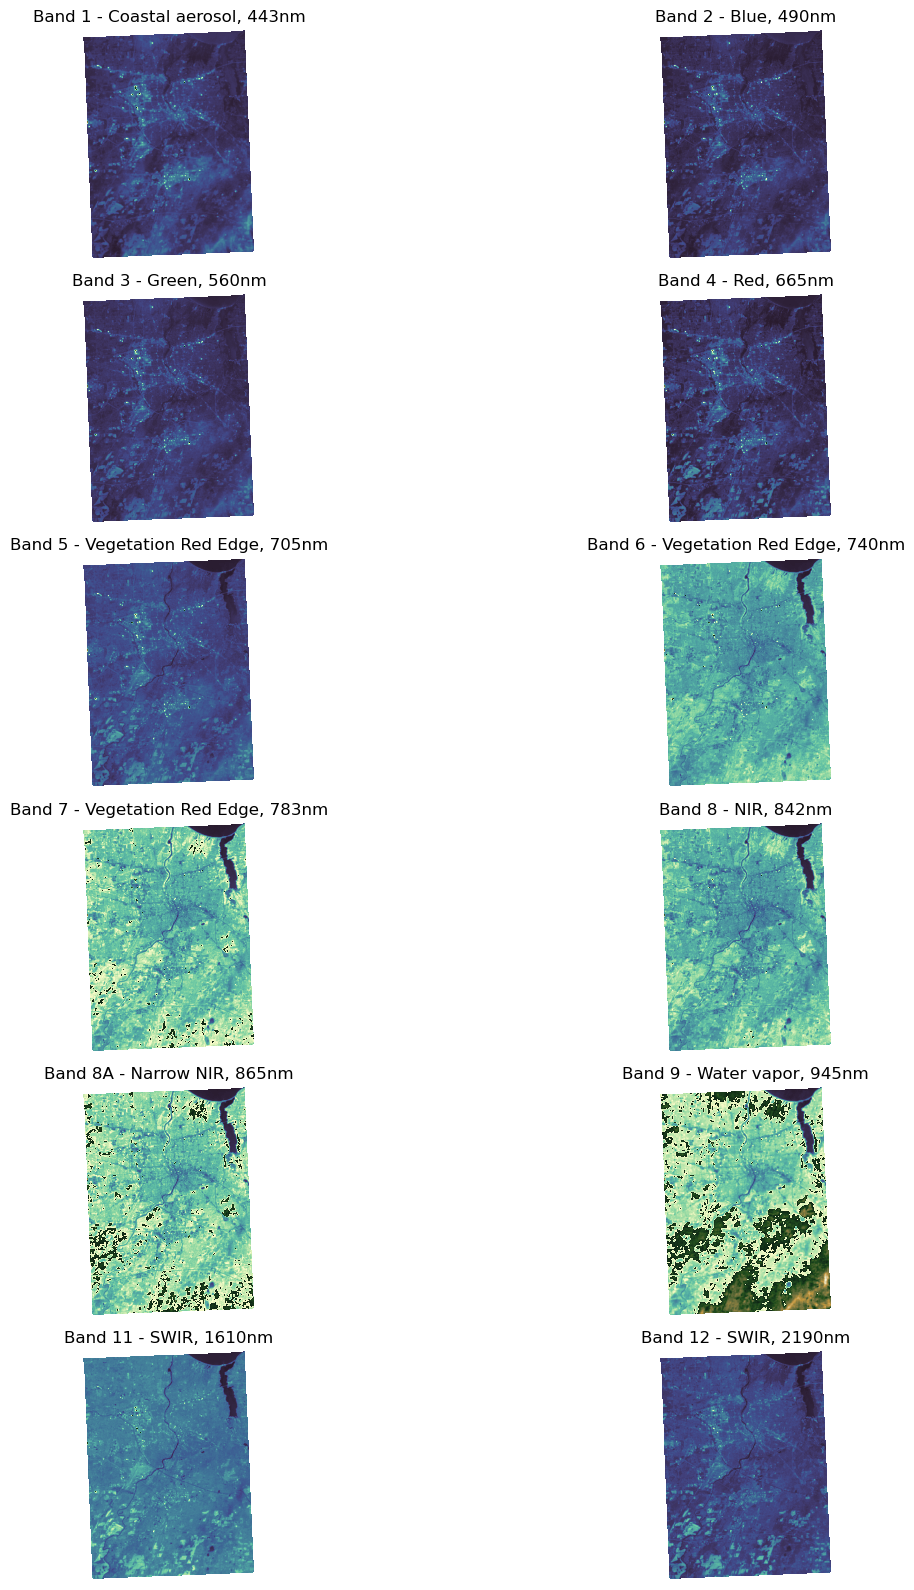

In [ ]:
#plot_bands(data, band_names)

# Problem 2
(a) Given the multi-spectral data for each band, define the function below that takes each band (treated as an independent random variable) and calculates the following statistics:
mean, standard deviation (std), minimum, maximum, quartiles (Q1, median, Q3), as well as skewness and kurtosis which was not covered in class. Explain what each of the statistics explain. Provide the statistics for all bands and all statistics as a table.

stats = calculate_band_statistics(args)

(b) Define another function called to standardize the data for each band. This function should compute the z-scores for all pixel values in the band. Explain what standardization does to your data. Plot the histogram for each band’s original data and use the standardize data to highlight the outliers. This approach helps to better understand the distribution of
the data and identify any anomalies present.

data_standard = standardize(data)


In [367]:
#Add explanation of what each statistic means, how they're calculated, and why they matter

def calculate_band_statistics(data, band_names):
    num_bands = data.shape[2]
    band_stats = []
    # Determine pixels for which all bands are zero, and set those pixels to NaN
    mask = np.all(data == 0, axis=2)
    data[mask] = np.nan
    for i in range(num_bands):
        band = data[:,:,i]
        band = band.flatten()
        mean = np.nanmean(band)
        std = np.nanstd(band)
        min_val = np.nanmin(band)
        max_val = np.nanmax(band)
        q1 = np.nanpercentile(band, 25)
        median = np.nanpercentile(band, 50)
        q3 = np.nanpercentile(band, 75)
        skewness = skew(band, nan_policy='omit', axis=None)
        kurt = kurtosis(band, nan_policy='omit', axis=None)
        band_stats.append({
            'band': band_names[i],
            'mean': mean,
            'std': std,
            'min': min_val,
            'max': max_val,
            'q1': q1,
            'median': median,
            'q3': q3,
            'skewness': skewness,
            'kurtosis': kurt
        })
    return pd.DataFrame(band_stats)

In [368]:
stats = calculate_band_statistics(data, band_names)
print(stats.to_markdown())

|    | band                                |      mean |       std |    min |    max |     q1 |   median |     q3 |   skewness |   kurtosis |
|---:|:------------------------------------|----------:|----------:|-------:|-------:|-------:|---------:|-------:|-----------:|-----------:|
|  0 | Band 1 - Coastal aerosol, 443nm     | 0.0886817 | 0.0279138 | 0.0333 | 0.6021 | 0.0709 |   0.0829 | 0.1007 |   2.92051  |   23.7974  |
|  1 | Band 2 - Blue, 490nm                | 0.0925416 | 0.0350015 | 0.0386 | 0.7542 | 0.0716 |   0.0853 | 0.1053 |   4.4789   |   43.108   |
|  2 | Band 3 - Green, 560nm               | 0.105496  | 0.0343652 | 0.043  | 0.7484 | 0.0858 |   0.0987 | 0.1168 |   4.69224  |   46.2931  |
|  3 | Band 4 - Red, 665nm                 | 0.0943111 | 0.0444543 | 0.0326 | 0.7728 | 0.0663 |   0.085  | 0.1093 |   3.23144  |   23.4076  |
|  4 | Band 5 - Vegetation Red Edge, 705nm | 0.136721  | 0.0409055 | 0.0346 | 0.8159 | 0.1152 |   0.131  | 0.1506 |   3.10802  |   27.3514  |
|  5 |

In [369]:
def standardize(data, plot_titles):
    #Calculate z-scores for all pixel values in each band
    #Z = (X - mu) / sigma
    #Plot each band with outliers highlighted
    #If Z > 3 or Z < -3, it's an outlier
    num_bands = data.shape[2]
    # Determine pixels for which all bands are zero, and set those pixels to NaN
    mask = np.all(data == 0, axis=2)
    data[mask] = np.nan

    for i in range(num_bands):
        band = data[:,:,i]
        mean = np.nanmean(band)
        stdev = np.nanstd(band)
        z_scores = (band - mean) / stdev
        outlier_mask = np.abs(z_scores) > 3
        #Use np.linspace to create evenly spaced bin edges, resulting in bins of equal width.
        bins = np.linspace(np.nanmin(band), np.nanmax(band), 100)
        plt.hist(band.flatten(), bins=bins, alpha=.9,color='blue', label='Original Data')
        plt.legend()
        plt.title(plot_titles[i])
        plt.show()
        plt.hist(z_scores.flatten(), bins=100, alpha=.9,color='purple', label='Standardized Data (Z-scores)')
        plt.axvline(3, color='red', linestyle='dashed', linewidth=2, label='Outlier Threshold (|z|=3)')
        plt.axvline(-3, color='red', linestyle='dashed', linewidth=2)
        plt.legend()
        plt.show()


In [370]:
#standardize(data, band_names)

# Problem 3
(a) We aim to explore the relationships between variables in the multispectral data. First,
use the concept of the Pearson r correlation coefficient, as discussed in class, to compute the
correlation matrix for all bands. Plot this matrix as an image, where each cell represents
the correlation between two bands. What type of matrix is this? Analyze the relationships
between variables and describe what the correlation coefficients reveal about their linear
relationships.

corr_matrix = correlation_matrix(args)

(b) For the 10-meter bands (B2, B3, B4, and B8), define a function that creates two subplots:
the first displaying a pairwise scatter plot between every two vectors, and the second showing
the density of scatter plot points in the scatter plot. The density plot is particularly useful for
visualizing areas where data points are more concentrated (there is more than one technique
to this; pick your favorite). Analyze the observed patterns and describe any significant trends
or clusters in the data.

corr_matrix = correlation_plot(args)

In [371]:
def correlation_matrix(data, band_short_names):
        num_bands = data.shape[2]
        df = pd.DataFrame()
        for i in range(num_bands):
                band = data[:,:,i]
                df[band_short_names[i]] = band.flatten()
        correlation_mat = df.corr()
        sns.heatmap(correlation_mat, annot = True)
        plt.show()

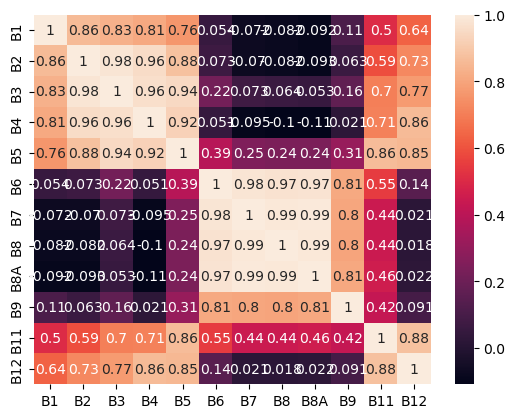

In [372]:
corr_matrix = correlation_matrix(data, band_short_names)

In [373]:
def correlation_plot(data, band_short_names):
        num_bands = data.shape[2]
        df = pd.DataFrame()
        for i in range(num_bands):
                band = data[:,:,i]
                df[band_short_names[i]] = band.flatten()
        ten_meter_bands = ['B2','B3','B4','B8']
        df = df[ten_meter_bands] #Plot only 10 meter bands
        for i in range(len(ten_meter_bands)):
                for j in range(i+1, len(ten_meter_bands)):
                        x = df[ten_meter_bands[i]]
                        y = df[ten_meter_bands[j]]
                        plt.figure()
                        plt.scatter(x, y)
                        plt.xlabel(ten_meter_bands[i])
                        plt.ylabel(ten_meter_bands[j])
                        plt.title(f'Scatter plot of {ten_meter_bands[i]} vs {ten_meter_bands[j]}')
                        plt.show()
                        sns.kdeplot(data=df, x=x, y=y, fill=True)
                        plt.show()

        

In [374]:
#correlation_plot(data, band_short_names)

# Problem 4

Visit JPL Spectral Library. ECOSTRESS data provides high-resolution lab-based spectral
reflectance across the electromagnetic spectrum, this data will be compared with the Sentinel-
2 data. Download spectral data covering the 0.35–2.5 micron wavelength range for the
two materials below:

1. Oak (Quercus genus) under the vegetation category.
2. Construction Asphalt or Road under the manmade category.

Note: You can order multiple spectra at a time, but you might have to wait to receive it via
email, you can also open the individual file and download the associated text file.

The spectral library data must be spectrally downsampled to the Sentinel-2 bands (Sentinel-
2 bands). Use the concept of cosine similarity to identify the first 100 pixels in Sentinel-2
data that have the lowest spectral angle (the obtained angle in the cosine similarly) when
compared to the ECOSTRESS samples. Plot the spectra of the 1st, 50th, and 100th closest
matches alongside the original ECOSTRESS spectra. Analyze how closely the matches
resemble the ECOSTRESS data and explain the similarities or differences. Pick a cut off
angle and use that as a threshold to grab all the vegetation/road pixels in your sentinel-2
imagery. Represent the pixels you have identified in the image with your favorite approach.
angle = sam(v1, v2)

Notes:
• Exclude sentinel 2 bands affected by atmospheric water absorption and aerosols (443
nm, 940 nm).
• Sentinel 2 Band 10 is excluded from the data.
• Divide the ECOSTRESS reflectance data by 100 as the range is 0-100.

In [375]:
tree_data = np.loadtxt('vegetation.tree.quercus.agrifolia.vswir.jpl108.jpl.asd.spectrum.txt', skiprows=21)
road_data = np.loadtxt('manmade.road.pavingasphalt.solid.all.0674uuuasp.jhu.becknic.spectrum.txt', skiprows=21)
#Divide reflectance values by 100 to convert to range 0-1
tree_data[:,1] = tree_data[:,1] / 100
road_data[:,1] = road_data[:,1] / 100

#Road data does extend beyond 2500nm, but Sentinel-2 does not go beyond 2200nm, so truncate road data to match assignment
road_data = road_data[road_data[:,0] <= 2500]

#Remove the two bands we don't need from the Sentinel-2 data (Bands 1 and 10)
bands_10 = np.delete(data, [0,9], axis=2)


In [376]:
band_central_wavelengths = [0.490, 0.560, 0.665, 0.705, 0.740, 0.783, 0.842, 0.865, 1.610, 2.190]

In [377]:
def downsample(wav_micron, reflec, target_wav):
    interp_func = interp1d(wav_micron, reflec, kind='linear', bounds_error=False, fill_value=np.nan)
    dwnsmpl_val = interp_func(target_wav)
    return dwnsmpl_val


def downsample_spectrum(data, band_central_wavelengths):
    downsampled_values = []
    for i in range(len(band_central_wavelengths)):
        downsampled_val = downsample(data[:,0], data[:,1], band_central_wavelengths[i])
        downsampled_values.append(downsampled_val)
    return np.array(downsampled_values)


In [378]:
tree_data_downsampled = downsample_spectrum(tree_data, band_central_wavelengths)
oak_data_downsampled = downsample_spectrum(road_data, band_central_wavelengths)
#

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

#Original code, pre-vectorized:

height, width, num_bands = bands_10.shape
similarity_map = np.zeros((height, width)) # To store the results


# Loop over each row (y-coordinate)

for y in range(height):

    for x in range(width):

# Extract the vector for the current pixel

# The ':' selects all 10 band values at this (y, x) location
        pixel_vector = bands_10[y, x, :]
        if np.any(np.isnan(pixel_vector)):
            similarity_map[y, x] = np.nan

else:
# Compare the pixel vector to the reference vector
    angle = cosine_similarity([pixel_vector], [tree_data_downsampled])
similarity_map[y, x] = angle

# --- 2. Reshape Data ---
pixel_matrix = bands_10.reshape(-1, 10)
reference_vector_2d = tree_data_downsampled.reshape(1, -1)


# --- 3. Mask NaNs and Calculate on Valid Data Only ---

# Create a boolean mask to find rows (pixels) that are ALL finite (not NaN or infinity)
# np.all(..., axis=1) checks each pixel's bands
valid_pixel_mask = np.all(np.isfinite(pixel_matrix), axis=1)

# Initialize a new array for all our scores, filling it with NaNs by default
num_pixels = pixel_matrix.shape[0]
all_scores_1d = np.full(num_pixels, np.nan)

# Now, calculate similarity ONLY on the clean pixels from the matrix
# This step is now safe and will not see any NaNs
valid_scores = cosine_similarity(pixel_matrix[valid_pixel_mask], reference_vector_2d)

# Place the calculated scores for valid pixels into the correct positions in our full array
all_scores_1d[valid_pixel_mask] = valid_scores.flatten()


# --- 4. Reshape the Final Result Back to an Image ---
similarity_map = all_scores_1d.reshape(pixel_matrix.shape[0], pixel_matrix.shape[1])


# --- 5. Verify Output ---
print(f"Shape of the final similarity map: {similarity_map.shape}")
print(f"Does the map contain NaNs? {np.isnan(similarity_map).any()}")
print(f"Were any valid scores calculated? {np.isfinite(similarity_map).any()}")

Shape of the final similarity map: (954, 716)
Does the map contain NaNs? True
Were any valid scores calculated? True


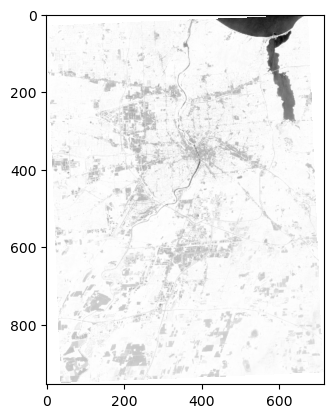

In [390]:
vmin = np.nanmin(similarity_map)
vmax = np.nanmax(similarity_map)
plt.imshow(similarity_map, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()